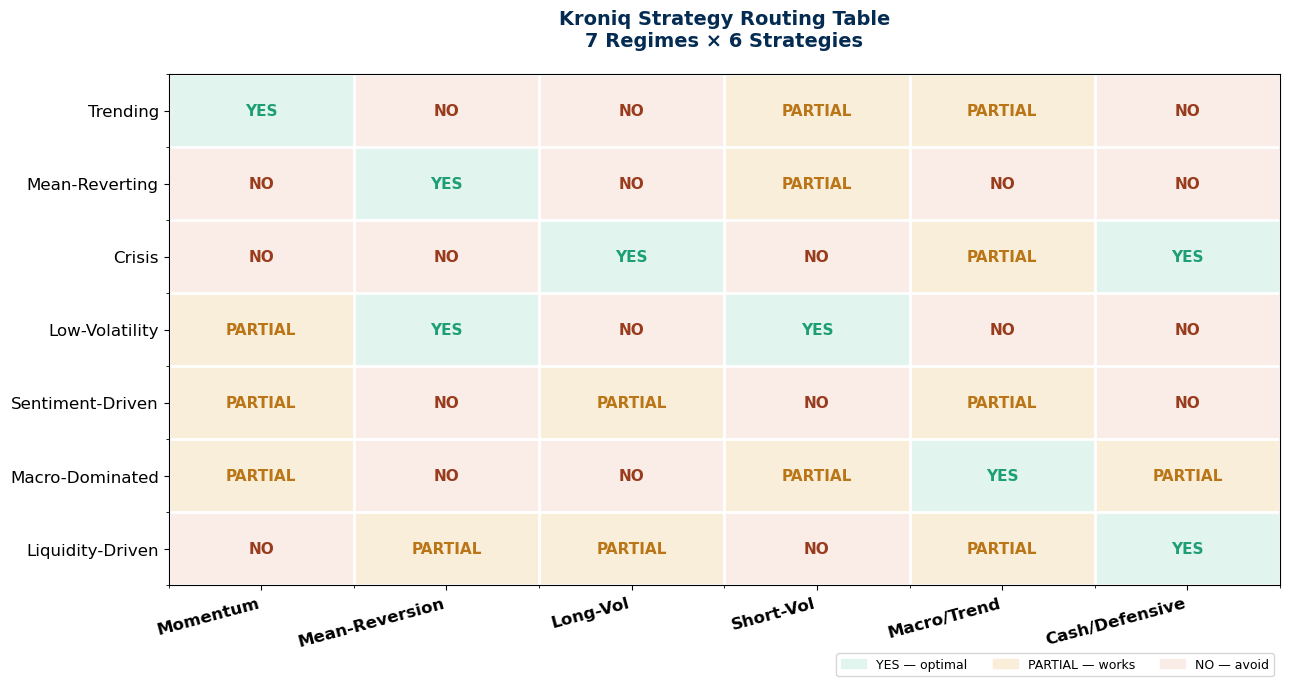

Engine 2 first form — done.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

regimes = ["Trending","Mean-Reverting","Crisis",
           "Low-Volatility","Sentiment-Driven",
           "Macro-Dominated","Liquidity-Driven"]

strategies = ["Momentum","Mean-Reversion",
              "Long-Vol","Short-Vol","Macro/Trend","Cash/Defensive"]

# 2=YES  1=PARTIAL  0=NO
data = {
    "Momentum":       [2,0,0,1,1,1,0],
    "Mean-Reversion": [0,2,0,2,0,0,1],
    "Long-Vol":       [0,0,2,0,1,0,1],
    "Short-Vol":      [1,1,0,2,0,1,0],
    "Macro/Trend":    [1,0,1,0,1,2,1],
    "Cash/Defensive": [0,0,2,0,0,1,2],
}
df = pd.DataFrame(data, index=regimes)

fig, ax = plt.subplots(figsize=(13,7))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "kroniq",["#FAECE7","#FAEEDA","#E1F5EE"])
ax.imshow(df.values, cmap=cmap, aspect="auto", vmin=0, vmax=2)
ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(strategies,fontsize=12,fontweight="bold",
                   rotation=15,ha="right")
ax.set_yticks(range(len(regimes)))
ax.set_yticklabels(regimes,fontsize=12)

label_map={0:"NO",1:"PARTIAL",2:"YES"}
color_map={0:"#993C1D",1:"#BA7517",2:"#1D9E75"}
for i in range(len(regimes)):
    for j in range(len(strategies)):
        val=df.values[i,j]
        ax.text(j,i,label_map[val],ha="center",va="center",
                fontsize=11,fontweight="bold",color=color_map[val])

ax.set_xticks(np.arange(-0.5,len(strategies),1),minor=True)
ax.set_yticks(np.arange(-0.5,len(regimes),1),minor=True)
ax.grid(which="minor",color="white",linewidth=2)
ax.set_title("Kroniq Strategy Routing Table\n7 Regimes × 6 Strategies",
             fontsize=14,fontweight="bold",pad=20,color="#042C53")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#E1F5EE",label="YES — optimal"),
    Patch(color="#FAEEDA",label="PARTIAL — works"),
    Patch(color="#FAECE7",label="NO — avoid"),
],loc="upper right",bbox_to_anchor=(1.0,-0.12),ncol=3,fontsize=9)
plt.tight_layout()
plt.savefig("kroniq_regime_routing_table.png",dpi=150,bbox_inches="tight")
plt.show()
print("Engine 2 first form — done.")